# 06 - Operational design domain and the integrity score

**Goal.** Turn the three trust signals - epistemic uncertainty (notebook 04), the
model-based NIS (notebook 05), and operating-domain membership - into a single,
decision-relevant **integrity score** $I\in[0,1]$. We treat the signals as
complementary *detectors*, fuse them with a rule that is safe by construction, and
measure the result with ROC and detection-delay analysis.

## 1. The ODD as set membership under uncertainty

The **operational design domain (ODD)** is the set of conditions a system was
designed and validated for [1,2]. Formally it is a set $\mathcal D$ in condition
space, and monitoring is a membership test $c_k\in\mathcal D$:

$$ \mathcal D=\{\,c:\ |\kappa|<\kappa_{\max},\ b>b_{\min},\ \sigma_{blur}<\sigma_{\max},\ o<o_{\max}\,\}. $$

Leaving $\mathcal D$ is a form of **novelty / anomaly detection** [9]: the input is
unlike the design population. Two subtleties matter. First, the conditions $c_k$ are
not known exactly - they are *estimated* from the image (the pixel features of
notebook 03), so the test must cope with **uncertain measurements** [3]. Second, a
hard indicator $\mathbb 1[c\in\mathcal D]$ chatters at the boundary; we prefer a
*soft* margin. For each guard define a signed normalised margin (positive = inside)
and pass the worst one through a logistic:

$$ m_j(c)=1-\frac{|c_j|}{c_{j,\max}}\ \text{(etc.)},\qquad
   s_{ODD}(c)=\sigma_L\!\big(\beta\,\min_j m_j\big),\quad \sigma_L(z)=\frac{1}{1+e^{-z}}. $$

## 2. Three detectors, three soft scores

Each signal is a *detector* of untrustworthiness, mapped monotonically to a trust
score in $[0,1]$ (1 = trustworthy):

$$ s_{unc}=\exp\!\Big(-\frac{\mathrm{tr}\,\Sigma^{AI}}{\sigma_{ref}}\Big),\qquad
   s_{NIS}=\exp\!\Big(-\frac{(\mathrm{NIS}-\chi^2_{m,1-\alpha})^+}{c}\Big),\qquad
   s_{ODD}=\sigma_L\!\big(\beta\min_j m_j\big). $$

The shapes are deliberate. $s_{unc}$ and $s_{NIS}$ use exponential decays so a
score behaves like a soft likelihood that falls off as the statistic worsens;
$s_{NIS}$ only reacts to the *excess* above its chi-squared threshold, so a
consistent filter scores $\approx 1$. Each detector is sensitive to a *different*
failure mode, which is the whole reason to fuse them.

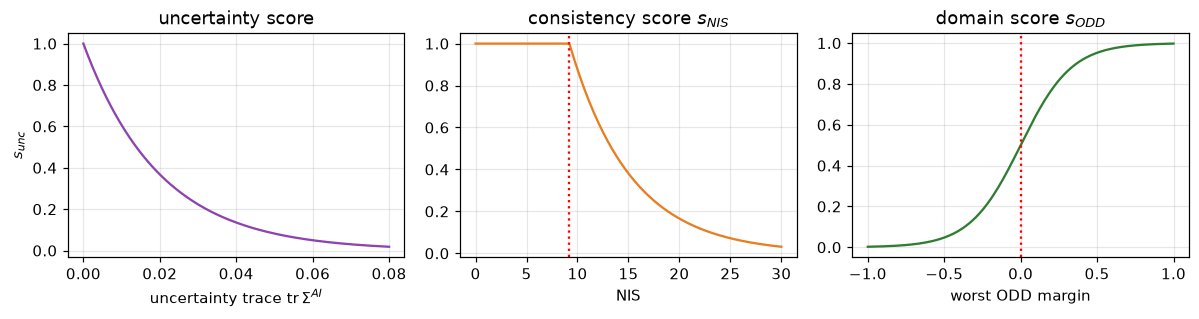

In [1]:
import numpy as np, matplotlib.pyplot as plt
CHI2 = 9.210
sigmaL = lambda z: 1/(1 + np.exp(-z))

def s_unc(trace, ref=0.02): return np.exp(-trace/ref)
def s_nis(nis, scale=6.0):   return np.exp(-np.maximum(0, nis - CHI2)/scale)
def s_odd(margin):           return sigmaL(6*margin)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
tr = np.linspace(0, 0.08, 200); ax[0].plot(tr, s_unc(tr), color="#8e44ad")
ax[0].set(xlabel="uncertainty trace $\\mathrm{tr}\\,\\Sigma^{AI}$", ylabel="$s_{unc}$", title="uncertainty score")
ni = np.linspace(0, 30, 200);  ax[1].plot(ni, s_nis(ni), color="#e67e22")
ax[1].axvline(CHI2, ls=":", color="r"); ax[1].set(xlabel="NIS", title="consistency score $s_{NIS}$")
mg = np.linspace(-1, 1, 200);  ax[2].plot(mg, s_odd(mg), color="#2e7d32")
ax[2].axvline(0, ls=":", color="r"); ax[2].set(xlabel="worst ODD margin", title="domain score $s_{ODD}$")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Fusing the detectors

How should three trust scores combine into one? Read each $s_i$ as a soft estimate
of $P(\text{trustworthy}\mid \text{signal}_i)$. Under a **naive-Bayes** assumption
(signals conditionally independent given trust), the combined posterior evidence
*multiplies* - the log-scores add. This is the **product rule** for combining
classifiers [4,5]:

$$ \boxed{\;I_{raw}=s_{unc}\cdot s_{NIS}\cdot s_{ODD}\;} $$

The product implements a logical **AND / independent veto**: *every* detector must be
happy for $I$ to be high, and any one collapsing to $0$ vetoes trust. That is the
safe choice - a fail-operational system should distrust the perception if *any*
credible signal says so. Contrast the average $\tfrac13\sum_i s_i$, which lets two
happy detectors *mask* one that has detected a real fault. We finally low-pass the
score to avoid chatter, a first-order recursion (EMA) with smoothing $\beta$:

$$ I_k=(1-\beta)\,I_{k-1}+\beta\,I_{raw,k}. $$

(The independence assumption is only approximate - blur, say, raises both $s_{unc}$
and $s_{ODD}$ - so the product is a conservative, well-behaved heuristic rather than
an exact posterior.)

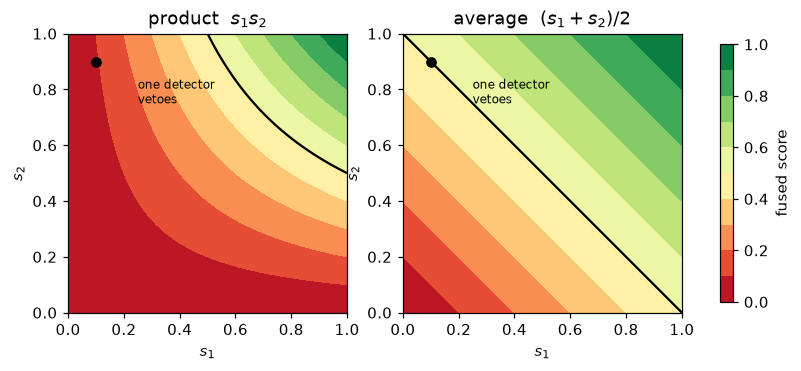

At (s1, s2) = (0.1, 0.9):  product = 0.09 (veto) ,  average = 0.50 (would pass)


In [2]:
# Product vs average: the weakest-link (veto) property
a = np.linspace(0, 1, 200); b = np.linspace(0, 1, 200); Aa, Bb = np.meshgrid(a, b)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for axi, (Z, name) in zip(ax, [(Aa*Bb, "product  $s_1 s_2$"), ((Aa+Bb)/2, "average  $(s_1+s_2)/2$")]):
    im = axi.contourf(Aa, Bb, Z, levels=np.linspace(0, 1, 11), cmap="RdYlGn")
    axi.contour(Aa, Bb, Z, levels=[0.5], colors="k", linewidths=1.5)
    axi.plot(0.1, 0.9, 'ko'); axi.annotate("one detector\nvetoes", (0.1, 0.9), xytext=(0.25, 0.75),
              textcoords="axes fraction", fontsize=8)
    axi.set(xlabel="$s_1$", ylabel="$s_2$", title=name); axi.set_aspect("equal")
fig.colorbar(im, ax=ax, shrink=.8, label="fused score")
plt.show()
print("At (s1, s2) = (0.1, 0.9):  product = %.2f (veto) ,  average = %.2f (would pass)" % (0.1*0.9, (0.1+0.9)/2))

## 4. Does fusion actually help? ROC and detection delay

To evaluate detectors we need ground truth. We build a scenario with **two
different faults**, and label each instant "untrustworthy" when a fault is present:

- a **blur** episode (heavy defocus): raises the perception uncertainty, and is
  visible in the pixel features, so $s_{unc}$ and $s_{ODD}$ should catch it - but the
  filter's $R$ grows honestly with the noise, so the **NIS stays quiet**;
- an **unmonitored perception bias** (a sensor glitch / novel object, with the
  conditions looking perfectly normal): invisible to the uncertainty and domain
  monitors, but it makes the innovation inconsistent, so **only the NIS catches it**.

No single detector covers both. We compare them with a **ROC curve** (true- vs
false-positive rate as the alarm threshold sweeps) [6] and with **detection delay**
(time from fault onset to first alarm) [7].

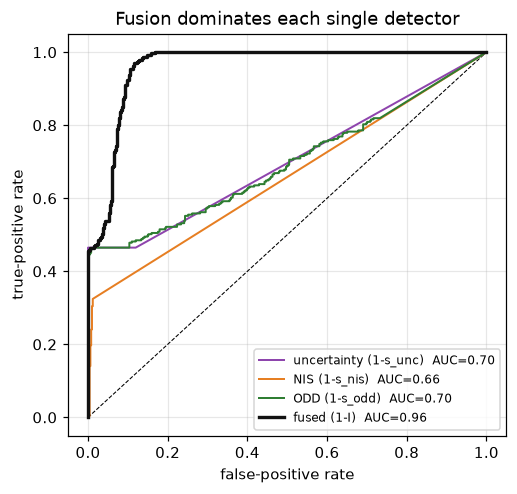

In [3]:
def build_scenario(N=800, Ts=0.05, seed=0):
    r = np.random.default_rng(seed)
    L, V = 2.7, 15.0
    A = np.array([[1, V*Ts], [0, 1.]]); C = np.eye(2); Qk = np.diag([1e-4, 1e-4])
    x = np.zeros(2); xhat = np.zeros(2); P = np.diag([0.05, 0.02])
    base = np.array([0.02, 0.01])
    S = {k: [] for k in ("s_unc", "s_nis", "s_odd", "I", "label")}
    def ramp(t, a, b, lo, hi): return lo if t<=a else hi if t>=b else lo+(hi-lo)*(t-a)/(b-a)
    Iprev = 1.0
    for k in range(N):
        t = k*Ts
        blur = ramp(t, 8, 11, 0, 2.6) if t < 14 else ramp(t, 16, 18, 2.6, 0)   # blur fault 8..18
        bright = 1 - 0.4*blur/2.6
        bias_on = 24 <= t < 32                                                  # unmonitored bias fault
        srep = base*(1 + 2.5*blur)*(1 + 1.5*max(0, 1 - bright))                 # honest noise level
        x = A @ x + r.multivariate_normal([0, 0], Qk)                           # true dynamics (u = 0)
        bias = np.array([0.20, 0.05]) if bias_on else np.zeros(2)
        y = C @ x + bias + r.normal(0, srep)
        # Kalman filter with honest claimed R = diag(srep^2)
        xp = A @ xhat; Pp = A @ P @ A.T + Qk
        nu = y - xp; Sn = Pp + np.diag(srep**2); nis = float(nu @ np.linalg.solve(Sn, nu))
        Kg = Pp @ np.linalg.inv(Sn); xhat = xp + Kg @ nu; P = (np.eye(2) - Kg) @ Pp
        # measured (noisy) pixel conditions for the ODD monitor
        blur_m = max(0, blur + r.normal(0, 0.15)); bright_m = np.clip(bright + r.normal(0, 0.05), 0, 1)
        margin = min((bright_m - 0.45)/0.55, 1 - blur_m/1.6)                    # pixel-only ODD guards
        su, sn, so = s_unc((srep**2).sum()), s_nis(nis), s_odd(margin)
        Iraw = su*sn*so; Iprev = 0.6*Iprev + 0.4*Iraw
        for key, val in zip(("s_unc","s_nis","s_odd","I"), (su, sn, so, Iprev)): S[key].append(val)
        S["label"].append((blur > 1.6) or bias_on)                             # ground-truth "untrustworthy"
    return {k: np.array(v) for k, v in S.items()}, Ts

def roc(score, label):
    thr = np.r_[np.inf, np.sort(np.unique(score))[::-1], -np.inf]
    P, Ng = label.sum(), (~label).sum()
    tpr = np.array([((score >= t) & label).sum()/max(P, 1) for t in thr])
    fpr = np.array([((score >= t) & ~label).sum()/max(Ng, 1) for t in thr])
    auc = float(np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2.0))   # trapezoid (numpy-version safe)
    return fpr, tpr, auc

sc, Ts = build_scenario()
label = sc["label"].astype(bool)
detectors = {"uncertainty (1-s_unc)": 1 - sc["s_unc"], "NIS (1-s_nis)": 1 - sc["s_nis"],
             "ODD (1-s_odd)": 1 - sc["s_odd"], "fused (1-I)": 1 - sc["I"]}
colors = {"uncertainty (1-s_unc)": "#8e44ad", "NIS (1-s_nis)": "#e67e22",
          "ODD (1-s_odd)": "#2e7d32", "fused (1-I)": "#111"}

plt.figure(figsize=(4.8, 4.6)); plt.plot([0,1],[0,1],'k--',lw=.7)
for name, score in detectors.items():
    fpr, tpr, auc = roc(score, label)
    plt.plot(fpr, tpr, color=colors[name], lw=(2.2 if "fused" in name else 1.3),
             label="%s  AUC=%.2f" % (name, auc))
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("Fusion dominates each single detector"); plt.legend(fontsize=8, loc="lower right")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [4]:
# Detection delay: threshold at the 90th percentile of each detector's nominal score,
# and require a SUSTAINED alarm (5 consecutive samples) so a lone spike does not count.
def alarm_threshold(score, label, target_fpr=0.10):
    return max(np.quantile(score[~label], 1 - target_fpr), 1e-3)

def first_delay(score, thr, window, hold=5):
    idx = np.where(window)[0]; onset = idx[0]
    fired = (score >= thr)
    for i in idx:
        if i + hold <= len(score) and fired[i:i+hold].all():
            return (i - onset)*Ts
    return None

blur_win = sc["label"] & (np.arange(len(label))*Ts < 20)     # the blur-fault interval
bias_win = sc["label"] & (np.arange(len(label))*Ts >= 20)    # the bias-fault interval
print("detector            blur-fault delay    bias-fault delay")
for name, score in detectors.items():
    thr = alarm_threshold(score, label)
    db = first_delay(score, thr, blur_win); dbi = first_delay(score, thr, bias_win)
    fmt = lambda d: ("%.2f s" % d) if d is not None else "  MISSED"
    print("%-18s  %14s    %14s" % (name.split(' ')[0], fmt(db), fmt(dbi)))

detector            blur-fault delay    bias-fault delay
uncertainty                 0.00 s            MISSED
NIS                         MISSED            1.75 s
ODD                         0.00 s            MISSED
fused                       0.00 s            0.30 s


The ROC and the delay table make the argument quantitatively: the uncertainty and
ODD monitors catch the blur fault but **miss** the unmonitored bias; the NIS catches
the bias but is (correctly) quiet during the honest-noise blur; and the fused score
catches *both*, with the highest AUC. This is exactly why the deployed system
(notebook 08) fuses all three rather than trusting any single signal - and why the
model-based NIS is indispensable for the failures the condition monitors cannot see.

## 5. Where this goes next

The integrity score is the single number the controller acts on. In notebook 07 it
sets the **authority** shared between automation and driver, $\lambda=\Phi(I,W)$, and
contracts the operating envelope, $v_{ref}=v_{nom}(0.4+0.6\,I)$. Because $I$ is
smooth and vetoed by the weakest detector, that hand-off is graceful rather than a
hard switch.

### Exercises

1. Replace the product with a **noisy-OR** on the alarms, $1-\prod_i(1-a_i)$, and
   compare its ROC to the product-of-trust rule. When would you prefer each?
2. Add a third fault type - low brightness at night - and check which detectors
   cover it. Does the fused AUC stay highest?
3. The independence assumption is false when blur raises both $s_{unc}$ and
   $s_{ODD}$. Estimate their correlation on the scenario; does double-counting make
   the product *too* conservative?
4. Tune the EMA $\beta$: plot detection delay vs false-alarm rate as $\beta$ varies.
   This is the responsiveness-vs-robustness trade you will meet again with CUSUM
   (notebook 09).

## References

1. SAE International. *Taxonomy and Definitions for Terms Related to Driving Automation Systems for On-Road Motor Vehicles.* Standard J3016_202104, 2021. (Operational design domain.)
2. P. Koopman, F. Fratrik. *How Many Operational Design Domains, Objects, and Events?* SafeAI Workshop, AAAI, 2019.
3. T. Charmet, V. Berge-Cherfaoui, J. Guzman, A. Armand. *Operational Design Domain Monitoring with Uncertain Measurements.* IEEE ITSC, 2024. doi:10.1109/ITSC58415.2024.10919733
4. J. Kittler, M. Hatef, R. P. W. Duin, J. Matas. *On Combining Classifiers.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 20(3):226-239, 1998. doi:10.1109/34.667881 (Product vs sum fusion rules.)
5. D. L. Hall, J. Llinas. *An Introduction to Multisensor Data Fusion.* Proceedings of the IEEE, 85(1):6-23, 1997. doi:10.1109/5.554205
6. T. Fawcett. *An Introduction to ROC Analysis.* Pattern Recognition Letters, 27(8):861-874, 2006. doi:10.1016/j.patrec.2005.10.010
7. M. Basseville, I. V. Nikiforov. *Detection of Abrupt Changes: Theory and Application.* Prentice Hall, 1993. (Detection delay and change detection.)
8. P. Antonante, H. Nilsen, L. Carlone. *Monitoring of Perception Systems: Deterministic, Probabilistic, and Learning-based Fault Detection and Identification.* Artificial Intelligence, 2022. arXiv:2205.10906
9. V. Chandola, A. Banerjee, V. Kumar. *Anomaly Detection: A Survey.* ACM Computing Surveys, 41(3):1-58, 2009. doi:10.1145/1541880.1541882